<a href="https://colab.research.google.com/github/yogevsim-bgu/franck-hertz/blob/main/Frank_Hertz_Exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Basics for Labs A and B

## Required Installs and Imports

In [130]:
!pip install -q matplotlib iminuit scikit-learn

In [131]:
# general python packages for classes, warning ,etc.
from abc import ABC, abstractmethod
from typing import Annotated
import warnings

# numpy for numeric calcualtion
import numpy as np
import seaborn as sns
# matplotlib for plotting
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

# iminuit as the minimizer
from iminuit import Minuit, describe
from iminuit.util import make_func_code, describe

# sklearn for goodness estimation methods
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scipy.stats.distributions import chi2 #this is for chi2 statistics there is likely a way to calculate (in particular p-value) from numpy or sklearn ...

%matplotlib inline
warnings.simplefilter("ignore")

## Class Definitions

We define here a base regressor class that has the responsibility to provide iminuit with the cost function value. It is also responsible to produce the goodness estimation and to plot the result via the show method.

All changes to the way the plots are presented should be modified here.

In [132]:
class Regressor(ABC):
    """
    Abstract base class for regressors compatible with Iminuit.
    To edit the plotting of the graph, edit the show method.
    """

    @abstractmethod
    def __init__(self, model : callable, x : list, y: list, dx : list, dy : list)->None:
        pass

    #this part defines the calculations when the function is called
    @abstractmethod
    def __call__(self, *par)->float:
        pass

    def goodness_estimator(self,optimizer : callable,method : str):
        """
        Performs goodness estimation given some metric (method).
        outputs 2 value of the goodness and the output string to be displayed.
        """
        self.goodness_methods = ["chi2","mse","mae","r2"]
        y_pred = self.model(self.x, *self.par_values)
        if method not in self.goodness_methods:
            raise ValueError(f"No method of type {method} are available.\n Choose one from {[item for item in self.goodness_methods]}")
        if method == "mse":
            return mean_squared_error(y_pred=y_pred,y_true=self.y) , f"MSE = {mean_squared_error(y_pred=y_pred,y_true=self.y):.4f}"
        if method == "mae":
            return mean_absolute_error(y_pred=y_pred,y_true=self.y) , f"MAE = {mean_absolute_error(y_pred=y_pred,y_true=self.y):.4f}"
        if method == "r2":
            return r2_score(y_pred=y_pred,y_true=self.y) , f"$R^2$ = {r2_score(y_pred=y_pred,y_true=self.y):.4f}"
        if method == "chi2":
            self.par = optimizer.parameters
            self.chi2 = optimizer.fval
            self.ndof = len(self.x) - len(self.par)
            self.chi_ndof = self.chi2 / self.ndof
            return self.chi_ndof , f"$\chi^2$ / ndof = {self.chi_ndof:.4f}({self.chi2:.4f}/{self.ndof})"


    def show(self, optimizer : callable , x_title="X", y_title="Y",plot_title=None, goodness_loc=2,legend_loc='best',show_grid=False,sig_digits=3,metric="chi2"):
        """
        Plots and displays the graph.
        """
        self.par        = optimizer.parameters
        self.par_values = optimizer.values
        self.par_errors = optimizer.errors
        text=""
        for p in (self.par):
            text += rf"{p} = {self.par_values[p]:.{sig_digits}f} $\pm$ {self.par_errors[p]:.{sig_digits}f}" + "\n"
        self.goodness_metric, metric_text = self.goodness_estimator(optimizer,method=metric)
        text = text + metric_text

        self.func_x = np.linspace(self.x[0],self.x[-1] ,10000) # 10000 linearly spaced numbers
        self.y_fit = self.model(self.func_x, *self.par_values)

        plt.rc("font", size=16)
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_axes([0,0,1,1])
        if plot_title is not None:
            ax.set_title(plot_title)
        ax.plot(self.func_x,self.y_fit,label="Fit") #plot the function over 10k points covering the x axis
        ax.scatter(self.x,self.y, c="red")
        ax.errorbar(self.x, self.y, self.dy, self.dx,fmt='none',ecolor='red', capsize=3,label="Data")
        ax.set_xlabel(x_title, fontdict={"size":21})
        ax.set_ylabel(y_title,fontdict={"size":21})
        ax.tick_params(axis="both",labelsize=18)
        anchored_text = AnchoredText(text, loc=goodness_loc)
        ax.add_artist(anchored_text)
        ax.legend()
        plt.grid(show_grid)

    def get_mean_uncertainty(self, optimizer : callable)->float:
        self.par        = optimizer.parameters
        self.par_values = optimizer.values
        self.par_errors = optimizer.errors
        self.y_fit = self.model(self.x, *self.par_values)
        return np.sqrt( ((self.y-self.y_fit)**2).sum()/(self.ndof) )


    def plot_residuals(self, optimizer : callable,x_title="X", y_title="Residuals", plot_lines=False, plot_title=None,):
        self.par        = optimizer.parameters
        self.par_values = optimizer.values
        self.par_errors = optimizer.errors
        self.y_fit = self.model(self.x, *self.par_values)
        self.residuals = self.y - self.y_fit
        residual_mean = np.mean(self.residuals)
        residual_std  = np.std(self.residuals,ddof=len(self.par)) #ddof because that's how much we are taking out with the fit &matches get_mean_uncertainty see https://numpy.org/doc/2.1/reference/generated/numpy.std.html
        plt.rc("font", size=16)
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_axes([0,0,1,1])
        if plot_title is not None:
            ax.set_title(plot_title)
        ax.scatter(self.x,self.residuals, c="black")
        ax.errorbar(self.x, self.residuals, self.dy,fmt='none',ecolor='black')
        ax.set_xlabel(x_title, fontdict={"size":21})
        ax.set_ylabel(y_title,fontdict={"size":21})
        ax.tick_params(axis="both",labelsize=18)
        plt.axhline(y=0, color='black', linestyle='-')
        if (plot_lines == True):
          plt.axhline(y=residual_mean, color='blue', linestyle='--', label=f"Mean: {residual_mean:.3f}")
          plt.axhline(y=residual_mean + residual_std, color='red', linestyle='--', label=f"Mean ± (STD = {residual_std:.3f})")
          plt.axhline(y=residual_mean - residual_std, color='red', linestyle='--')
        ax.legend(loc="upper right", fontsize=14)




The following 2 classes are specific implementations of the base regressor class. The first is the Least Squares Regressor following the least squares algorithm. Notice that this algorithm totally ignore uncertainties!

The 2nd regressor is the Chi2 regressor. It can handle uncertainties in both x and y. If there are no dx, set them all to 0 or input only dy.

In [133]:
class LeastSquaresReg(Regressor):
    errordef = Minuit.LEAST_SQUARES  # for Minuit to compute errors correctly

    def __init__(self, model, x, y, dx=None, dy=None)->None:
        self.model = model  # model predicts y for given x
        self.x = np.asarray(x)
        self.y = np.asarray(y)
        if dx is not None:
          print("This is least squares regressor. dx will be ignored!")
        if dy is not None:
          print("This is least squares regressor. dy will be ignored!")
        self.dx = np.zeros(x.shape)
        self.dy = np.zeros(y.shape)
        super().__init__(model, x, y, dx, dy)
        pars = describe(model, annotations=True)
        model_args = iter(pars)
        next(model_args)
        self._parameters = {k: pars[k] for k in model_args}


    @property
    def ndata(self):
        return len(self.x)

    def __call__(self, *par)->float:  # we must accept a variable number of model parameters
        ym = self.model(self.x, *par)
        return np.sum((self.y - ym) ** 2)





In [134]:
class Chi2Reg(Regressor):  #This class is for Chi2 Regression and if dx is provided uses the effective variance method.
    #this part defines the variables the class will use
    def __init__(self, model, x, y, dx=None, dy=None):
        self.model = model  # model predicts y value for given x value
        self.x  = np.asarray(x) #the x values
        self.y  = np.asarray(y) #the y values
        if dx is None:
          self.dx = np.zeros(x.shape)
        else:
          self.dx = np.asarray(dx)
        if dy is None:
          raise ValueError("Uncertainties on y were not provided!")
        self.dy = np.asarray(dy) #the y-axis uncertainties
        self.func_code = make_func_code(describe(self.model)[1:])
        self.h = (x[-1]-x[0])/10000  #this is the step size for the numerical calculation of the df/dx = last value in x (x[-1]) - first value in x (x[0])/10000

    @property
    def ndata(self):
        return len(self.x)


    def __call__(self, *par):  # par are a variable number of model parameters
        self.ym = self.model(self.x, *par)
        df = (self.model(self.x + self.h, *par)-self.ym)/self.h #the derivative df/dx at point x is taken as [f(x+h)-f(x)]/h
        chi2 = sum(((self.y - self.ym)**2)/(self.dy**2+(df * self.dx)**2))#chi2 is now Sum of: (f(x)-y)^2/(uncert_y^2+(df/dx*uncert_x)^2)
        return chi2



## Examples - Using the classes to fit

We start by defining the measurements and uncertainties

Then we define the function to fit

In [135]:
linear_fun = lambda x,a,b: a + (x * b)
exp_fun    = lambda x,a,b: a*np.exp(x*b)
power_fun  = lambda x,a,b,c: a*x**b + c
parab_fun  = lambda x,a,b,c: a*x**2 + b*x + c


And if we want to see the covariance matrix we can

In [136]:
import pandas as pd

# Load experiment measurement files explicitly as CSV
exp2m1_df = pd.read_csv('exp2m1.csv')
exp2m2_df = pd.read_csv('exp2m2.csv')


Renamed columns in exp1m1_df.
Plotting exp1m1_df:
Renamed columns in exp1m2_df.
Plotting exp1m2_df:


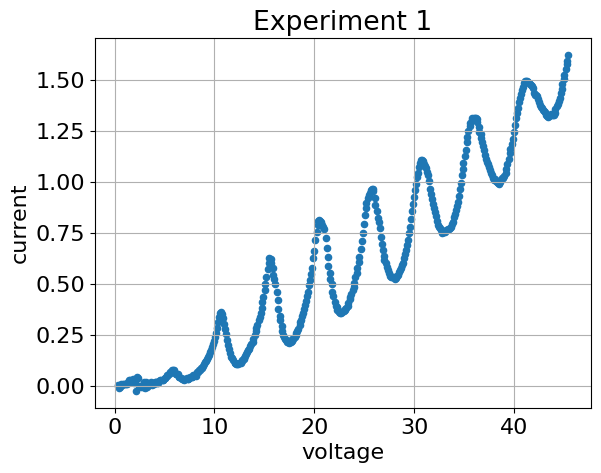

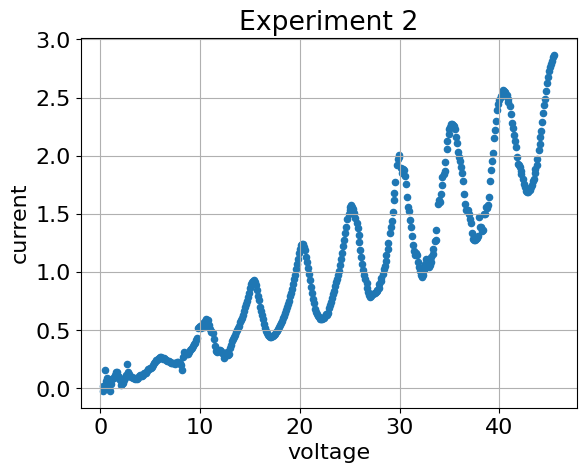

In [137]:
# Create a list of all experiment dataframes
experiment_dfs = [
    exp2m1_df, exp2m2_df
]
# Rename columns and plot for all dataframes in the list
for i, df in enumerate(experiment_dfs):
    df_name = f'exp1m{i+1}_df'
    # Rename columns
    if 'Voltage (V)' in df.columns and 'Current (a.u.)' in df.columns:
        df.rename(columns={'Voltage (V)': 'voltage', 'Current (a.u.)': 'current'}, inplace=True)
        print(f"Renamed columns in {df_name}.")

    # Plot using the new column names
    print(f"Plotting {df_name}:")
    df.plot(x='voltage', y='current', kind='scatter', title=f'Experiment {i+1}', grid=True)

In [138]:
parab_min_representation = lambda v, v0, c:  ((v- v0)**2)+c

In [139]:
def get_points_between_voltages(vi_df,starting_voltage, ending_voltage):
  return vi_df[(vi_df['voltage'] >= starting_voltage) & (vi_df['voltage'] <= ending_voltage)]

In [140]:
def get_chi2_for_voltage_range(vi_df,starting_voltage, ending_voltage,dI,multiplier, dv=None):
  truncated_data = get_points_between_voltages(vi_df,starting_voltage, ending_voltage)
  if truncated_data.empty:
    return None
  v = truncated_data['voltage'].to_numpy()
  if len(v) <= 2:
    return 0
  I = truncated_data['current'].to_numpy()*multiplier
  if dv is None:
    dv = [0.1] * len(I)

  chi2 = Chi2Reg(parab_min_representation, v, I, dy=[dI]*len(I), dx=dv)
  m = Minuit(chi2, v0=(starting_voltage + ending_voltage)/2, c=0)
  m.migrad()
  current_chi2_ndof = m.fval/(len(v)-m.nfit)
  return current_chi2_ndof, m

In [141]:
def get_all_posible_ranges_chi2(vi_df, starting_voltage, ending_voltage, dI, multiplier, range=5):
  results_df = pd.DataFrame(columns=['starting_voltage', 'ending_voltage', 'chi2_ndof'])
  all_voltage_points_in_range = vi_df[(vi_df['voltage'] >= starting_voltage) & (vi_df['voltage'] <= ending_voltage)]['voltage'].unique()
  possible_starts = all_voltage_points_in_range[all_voltage_points_in_range <= starting_voltage + range]
  possible_ends = all_voltage_points_in_range[all_voltage_points_in_range >= ending_voltage - range]

  for starting_point in possible_starts:
    for end_point in possible_ends:
      if end_point <= starting_point:
        continue
      result = get_chi2_for_voltage_range(vi_df, starting_point, end_point, dI, multiplier)
      if result is None or result == 0:
        continue
      chi2_ndof, _ = result  # unpack tuple; store only the scalar
      results_df.loc[len(results_df)] = [starting_point, end_point, chi2_ndof]
  return results_df

In [142]:
def get_best_range(vi_df,starting_voltage, ending_voltage,dI, multiplier,range=5,heatmap=False):
  results_df = get_all_posible_ranges_chi2(vi_df,starting_voltage, ending_voltage,dI,multiplier, range=range)
  if heatmap:
    plt.figure(figsize=(10, 6))
    sns.heatmap(results_df.pivot(index='starting_voltage', columns='ending_voltage', values='chi2_ndof'), annot=False, fmt=".2f", cmap="PuRd_r", vmin=0, vmax=45)
  best_row = results_df.loc[(results_df['chi2_ndof'] -1).abs().idxmin()]
  return best_row

In [143]:
def calculate_dI(vi_df, multiplier,dead_zone_start=2, dead_zone_end=8):
  dead_data = vi_df[(vi_df['voltage'] >= dead_zone_start) & (vi_df['voltage'] <= dead_zone_end)]
  return dead_data['current'].std() * multiplier

In [144]:
def get_best_fit(vi_df, v_left, v_right, dI, multiplier,
                 min_margin=1.0, max_half_width=2.5, min_pts=10):
    """
    Find the parabolic fit window with chi2/ndof closest to 1.

    Anchors the search around the actual data minimum inside [v_left, v_right]:
      - possible starts  in  [v_min - max_half_width,  v_min - min_margin]
      - possible ends    in  [v_min + min_margin,       v_min + max_half_width]
    This guarantees the valley bottom is always inside the fit range and
    that there is at least min_margin V of data on each side.
    """
    valley_data = get_points_between_voltages(vi_df, v_left, v_right)
    if valley_data.empty:
        return None, v_left, v_right

    v_min_data = valley_data.loc[valley_data['current'].idxmin(), 'voltage']
    all_v = valley_data['voltage'].values

    possible_starts = all_v[(all_v >= v_min_data - max_half_width) & (all_v <= v_min_data - min_margin)]
    possible_ends   = all_v[(all_v >= v_min_data + min_margin)     & (all_v <= v_min_data + max_half_width)]

    if len(possible_starts) == 0 or len(possible_ends) == 0:
        return None, v_left, v_right

    best_dist, best_start, best_end, best_m = np.inf, possible_starts[0], possible_ends[-1], None

    for start in possible_starts:
        for end in possible_ends:
            if np.sum((all_v >= start) & (all_v <= end)) < min_pts:
                continue
            result = get_chi2_for_voltage_range(vi_df, start, end, dI, multiplier)
            if result is None or result == 0:
                continue
            chi2_ndof, m_candidate = result
            dist = abs(chi2_ndof - 1)
            if dist < best_dist:
                best_dist, best_start, best_end, best_m = dist, start, end, m_candidate

    return best_m, best_start, best_end

In [145]:
# Read multipliers from experiment metadata
meta_df = pd.read_csv('Exp 2 - Franck-Hertz Hg_Selection_2026-06-16_12-47.csv')

def parse_multiplier(gain_str):
    parts = gain_str.strip().split()          # e.g. ["5", "x1", "nA"]
    return int(parts[0]) * int(parts[1].lstrip('x'))  # 5 * 1 = 5

multipliers = {row['Curve ID']: parse_multiplier(row['Amp gain']) for _, row in meta_df.iterrows()}

mult1 = multipliers['exp2m1']   # "5 x1 nA"  → 5
mult2 = multipliers['exp2m2']   # "5 x10 pA" → 50

dI1 = calculate_dI(exp2m1_df, mult1)
dI2 = calculate_dI(exp2m2_df, mult2)

print(f"exp2m1  multiplier = {mult1},  dI = {dI1:.4f}")
print(f"exp2m2  multiplier = {mult2},  dI = {dI2:.4f}")

exp2m1  multiplier = 5,  dI = 0.1195
exp2m2  multiplier = 50,  dI = 3.4689


In [146]:
# Wide brackets covering the full valley period — the search is anchored to
# the data minimum inside each bracket, so exact edges don't need to be precise.
valley_ranges = [
    ( 9.5, 15.5),   # valley 1  ~12.2 V
    (14.5, 20.5),   # valley 2  ~17.5 V
    (19.5, 25.5),   # valley 3  ~22.7 V
    (24.5, 31.0),   # valley 4  ~28.1 V
    (29.5, 36.0),   # valley 5  ~32.8 V
    (35.0, 41.5),   # valley 6  ~38.6 V
    (40.5, 45.5),   # valley 7  ~43.4 V
]

def fit_all_valleys(vi_df, dI, multiplier, label):
    print(f"\n{'='*62}")
    print(f"  {label}")
    print(f"{'='*62}")
    results = []
    for i, (v_start, v_end) in enumerate(valley_ranges):
        m, best_start, best_end = get_best_fit(vi_df, v_start, v_end, dI, multiplier)
        if m is None:
            print(f"  Valley {i+1}: fit failed — check valley_ranges or margins")
            continue
        v0        = m.values['v0']
        v0_err    = m.errors['v0']
        c         = m.values['c']
        c_err     = m.errors['c']
        n_pts     = len(get_points_between_voltages(vi_df, best_start, best_end))
        chi2_ndof = m.fval / (n_pts - m.nfit)
        print(f"  Valley {i+1}: v0 = {v0:.3f} ± {v0_err:.3f} V  "
              f"| range [{best_start:.2f}, {best_end:.2f}] V  "
              f"| χ²/ndof = {chi2_ndof:.3f}  ({n_pts} pts)")
        results.append(dict(valley=i+1, v0=v0, v0_err=v0_err,
                            c=c, c_err=c_err,
                            best_start=best_start, best_end=best_end,
                            chi2_ndof=chi2_ndof))
    df_out = pd.DataFrame(results)
    df_out['delta_v0']     = df_out['v0'].diff()
    df_out['delta_v0_err'] = np.sqrt(df_out['v0_err']**2 + df_out['v0_err'].shift(1)**2)
    return df_out

minima_m1 = fit_all_valleys(exp2m1_df, dI1, mult1,
                            label=f"Experiment 2 – Measurement 1  (multiplier={mult1})")
minima_m2 = fit_all_valleys(exp2m2_df, dI2, mult2,
                            label=f"Experiment 2 – Measurement 2  (multiplier={mult2})")

print("\n\n--- Minima (exp2m1) ---")
print(minima_m1[['valley','v0','v0_err','delta_v0','delta_v0_err','chi2_ndof']].to_string(index=False))

print("\n--- Minima (exp2m2) ---")
print(minima_m2[['valley','v0','v0_err','delta_v0','delta_v0_err','chi2_ndof']].to_string(index=False))


  Experiment 2 – Measurement 1  (multiplier=5)
  Valley 1: v0 = 12.294 ± 0.040 V  | range [11.18, 13.21] V  | χ²/ndof = 1.105  (21 pts)
  Valley 2: v0 = 17.483 ± 0.032 V  | range [16.01, 18.53] V  | χ²/ndof = 0.980  (26 pts)
  Valley 3: v0 = 22.668 ± 0.030 V  | range [21.02, 23.73] V  | χ²/ndof = 0.991  (28 pts)
  Valley 4: v0 = 28.048 ± 0.038 V  | range [27.04, 29.20] V  | χ²/ndof = 1.098  (22 pts)
  Valley 5: v0 = 32.959 ± 0.040 V  | range [31.79, 33.82] V  | χ²/ndof = 1.002  (21 pts)
  Valley 6: v0 = 38.515 ± 0.038 V  | range [37.56, 39.68] V  | χ²/ndof = 0.996  (22 pts)
  Valley 7: v0 = 43.495 ± 0.040 V  | range [42.43, 44.50] V  | χ²/ndof = 1.607  (22 pts)

  Experiment 2 – Measurement 2  (multiplier=50)
  Valley 1: v0 = 13.698 ± 0.329 V  | range [10.38, 13.51] V  | χ²/ndof = 0.999  (32 pts)
  Valley 2: v0 = 18.587 ± 0.515 V  | range [15.91, 18.20] V  | χ²/ndof = 0.979  (24 pts)
  Valley 3: v0 = 24.023 ± 0.591 V  | range [21.01, 23.12] V  | χ²/ndof = 1.148  (22 pts)
  Valley 4: v

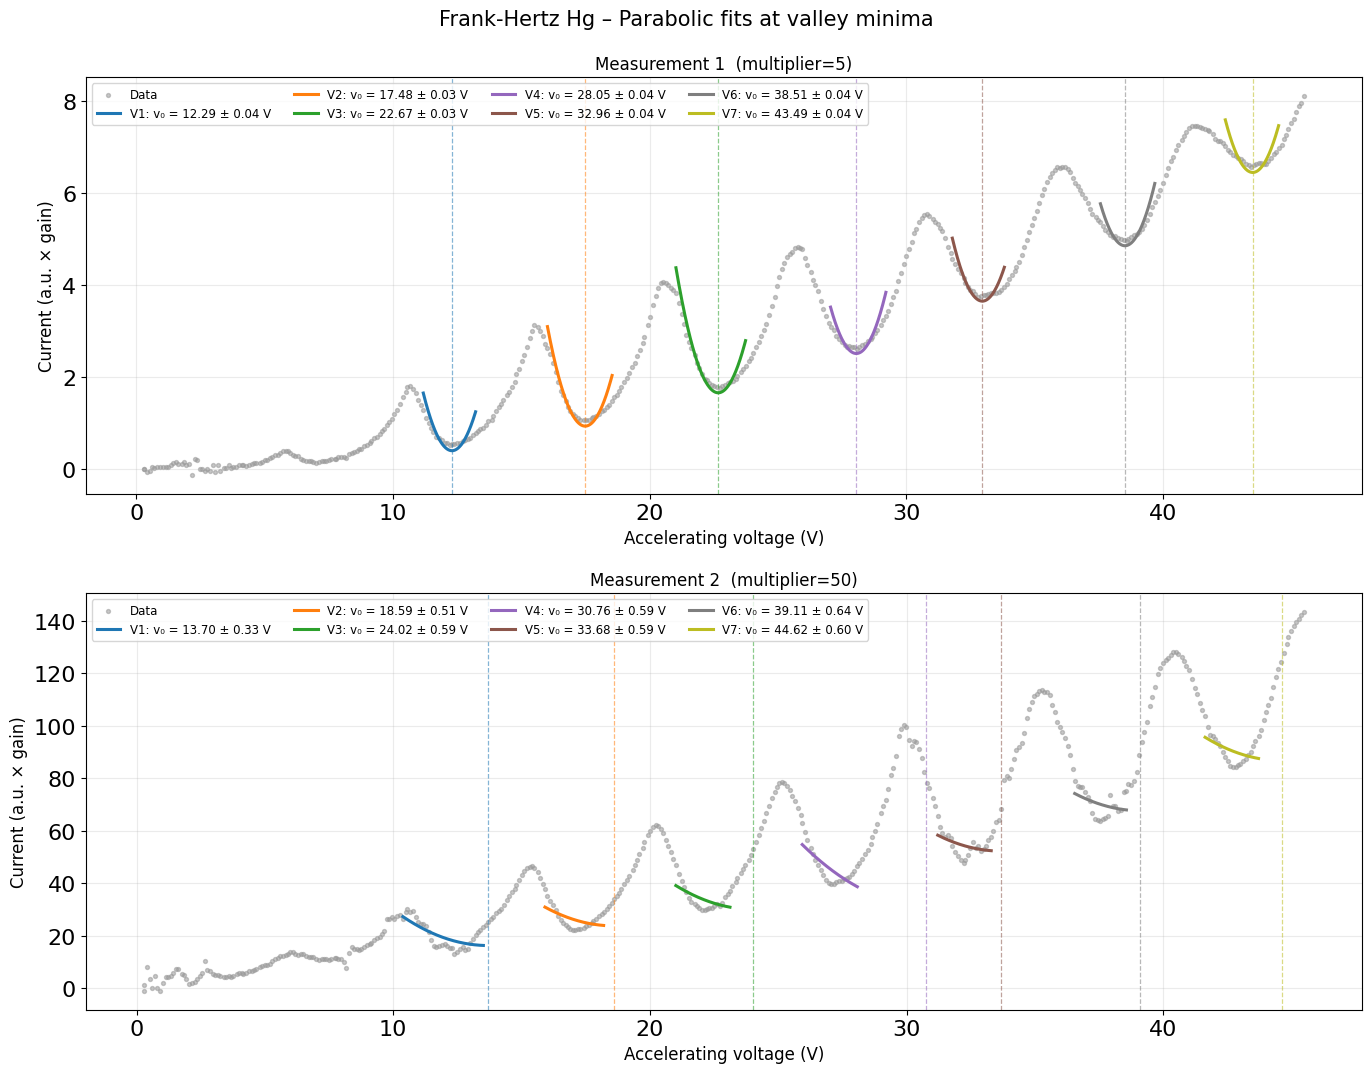

In [147]:
colors = plt.cm.tab10(np.linspace(0, 0.85, 7))

fig, axes = plt.subplots(2, 1, figsize=(14, 11))
fig.suptitle("Frank-Hertz Hg – Parabolic fits at valley minima", fontsize=15)

datasets = [
    (exp2m1_df, mult1, minima_m1, f"Measurement 1  (multiplier={mult1})"),
    (exp2m2_df, mult2, minima_m2, f"Measurement 2  (multiplier={mult2})"),
]

for ax, (df, mult, minima_df, title) in zip(axes, datasets):
    # Full I-V scatter
    ax.scatter(df['voltage'], df['current'] * mult, s=8, c='#999999',
               alpha=0.55, zorder=1, label='Data')

    for _, row in minima_df.iterrows():
        idx   = int(row['valley']) - 1
        color = colors[idx]
        v_fit = np.linspace(row['best_start'], row['best_end'], 500)
        I_fit = (v_fit - row['v0'])**2 + row['c']   # parab_min_representation in fit-scaled units
        ax.plot(v_fit, I_fit, color=color, linewidth=2.2, zorder=3,
                label=f"V{int(row['valley'])}: v₀ = {row['v0']:.2f} ± {row['v0_err']:.2f} V")
        ax.axvline(row['v0'], color=color, linestyle='--', linewidth=0.9, alpha=0.55, zorder=2)

    ax.set_xlabel("Accelerating voltage (V)", fontsize=12)
    ax.set_ylabel("Current (a.u. × gain)", fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8.5, ncol=4, loc='upper left')
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

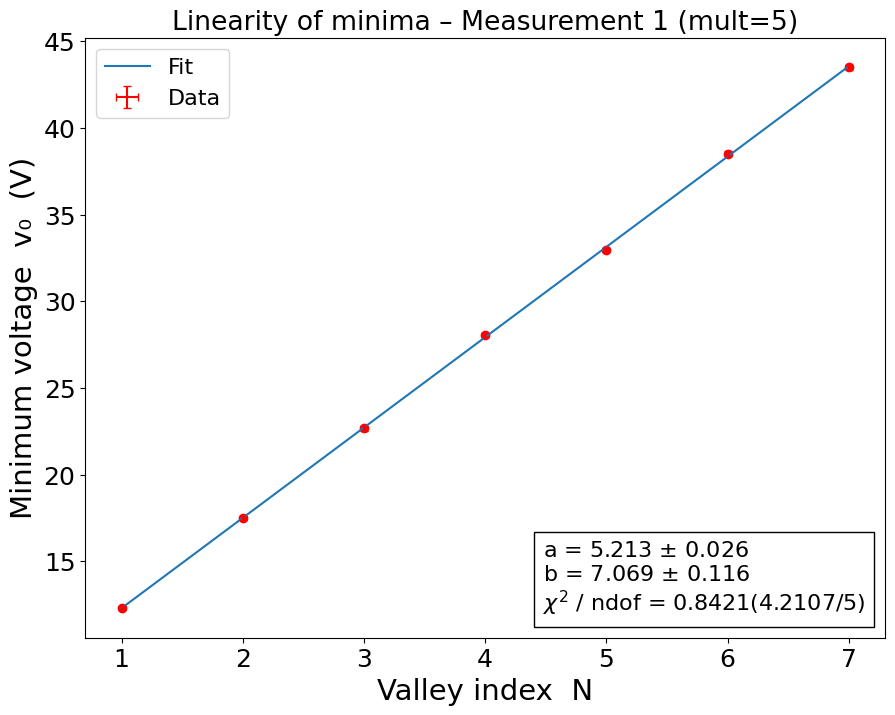

Measurement 1 (mult=5)
  a (spacing) = 5.2135 ± 0.0261 V / valley
  b (offset)  = 7.0691 ± 0.1155 V



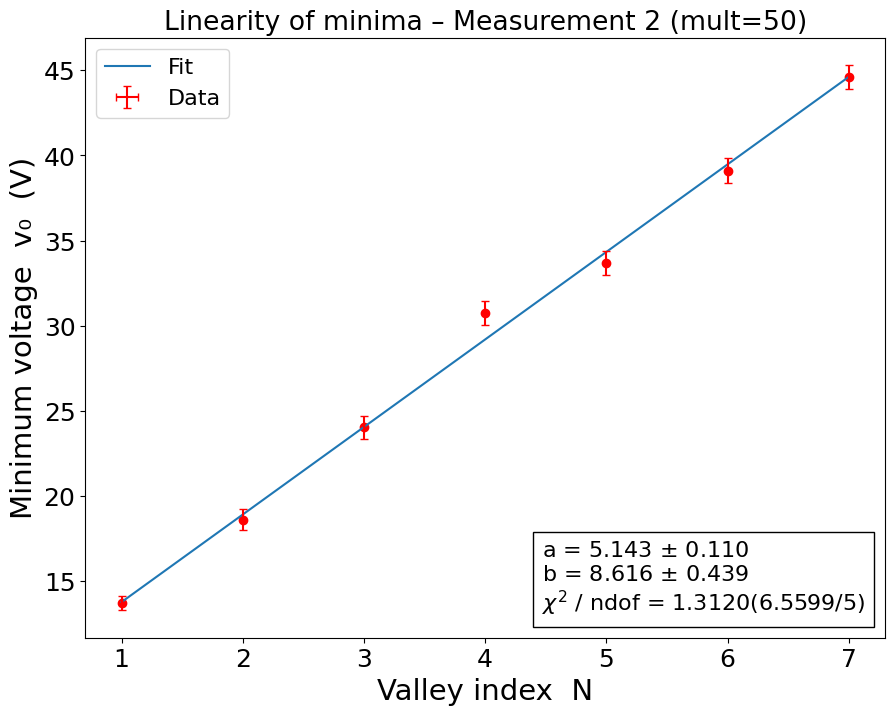

Measurement 2 (mult=50)
  a (spacing) = 5.1434 ± 0.1104 V / valley
  b (offset)  = 8.6165 ± 0.4386 V



In [150]:
linear_minima = lambda N, a, b: a * N + b   # V = a·N + b

for minima_df, label in [(minima_m1, f"Measurement 1 (mult={mult1})"),
                          (minima_m2, f"Measurement 2 (mult={mult2})")]:
    N   = minima_df['valley'].to_numpy(dtype=float)
    v0  = minima_df['v0'].to_numpy()
    dv0 = (minima_df['v0_err'] + 0.1 ).to_numpy()

    reg  = Chi2Reg(linear_minima, N, v0, dy=dv0)
    mopt = Minuit(reg, a=5.2, b=6.8)
    mopt.migrad()

    reg.show(mopt,
             x_title="Valley index  N",
             y_title="Minimum voltage  v₀  (V)",
             plot_title=f"Linearity of minima – {label}",
             goodness_loc=4,
             metric="chi2")
    plt.show()
    print(f"{label}")
    print(f"  a (spacing) = {mopt.values['a']:.4f} ± {mopt.errors['a']:.4f} V / valley")
    print(f"  b (offset)  = {mopt.values['b']:.4f} ± {mopt.errors['b']:.4f} V\n")